# Stage 7: Data Visualization
Capstone Project: Spam Message Analysis Using Malicious URLs

Seven charts: top TLDs, URL length by class, HTTPS by class, suspicious keywords, correlation heatmap, length vs digits scatter, and the confusion matrix. All charts are also saved to `results/graphs/`.

In [1]:
from pathlib import Path

# Project root = parent of this notebook's stage folder (run the notebook from inside its own folder)
ROOT = Path.cwd().parent
RAW_CSV = ROOT / "dataset" / "dataset.csv"
INTER = ROOT / "dataset" / "intermediate"      # output of each stage becomes input of the next
RESULTS = ROOT / "results"
GRAPH_DIR = RESULTS / "graphs"
for p in (INTER, RESULTS, GRAPH_DIR):
    p.mkdir(parents=True, exist_ok=True)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_final = pd.read_csv(INTER / "stage4_clean.csv", keep_default_na=False)

numeric_columns = [
    "url_length", "subdomain_count", "path_length", "query_length",
    "has_https", "has_ip_address", "dot_count", "hyphen_count",
    "digit_count", "special_char_count", "has_at_symbol",
    "has_shortener", "keyword_count"
]
corr_matrix = df_final[numeric_columns].corr()

# Predictions saved by Stage 6 (needed for the confusion matrix)
pred = pd.read_csv(RESULTS / "model_predictions.csv")


### Chart 1 — Top 10 TLDs

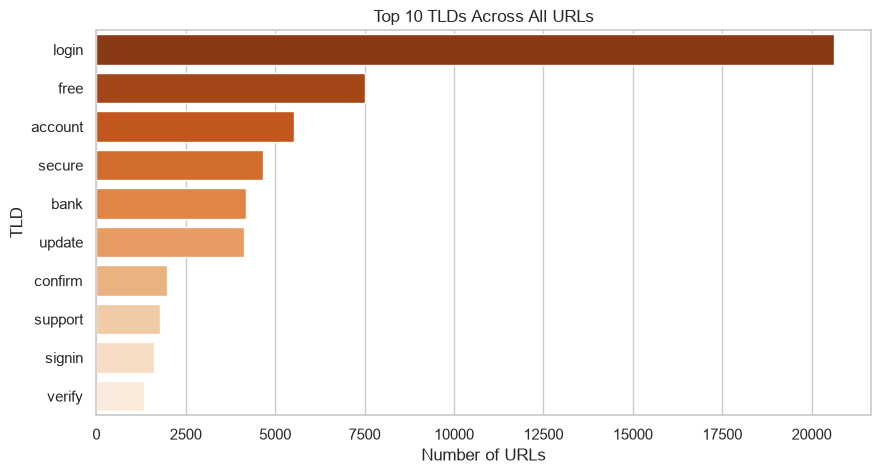

In [11]:
top_tlds = df_final["tld"].replace("", "unknown").value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, hue=top_keywords.index, palette="Oranges_r", legend=False)
plt.title("Top 10 TLDs Across All URLs")
plt.xlabel("Number of URLs")
plt.ylabel("TLD")
plt.savefig(GRAPH_DIR / "01_top_tlds.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 — URL length distribution by class

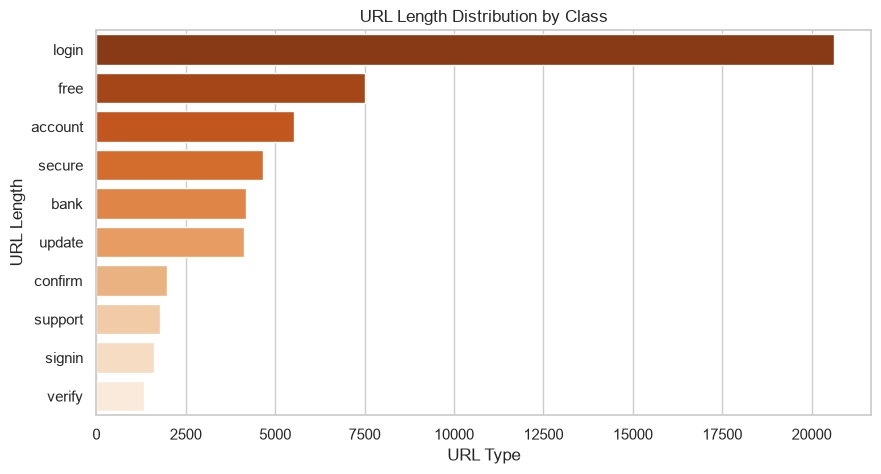

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, hue=top_keywords.index, palette="Oranges_r", legend=False)
plt.title("URL Length Distribution by Class")
plt.xlabel("URL Type")
plt.ylabel("URL Length")
plt.savefig(GRAPH_DIR / "02_url_length_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 — HTTP vs HTTPS by class

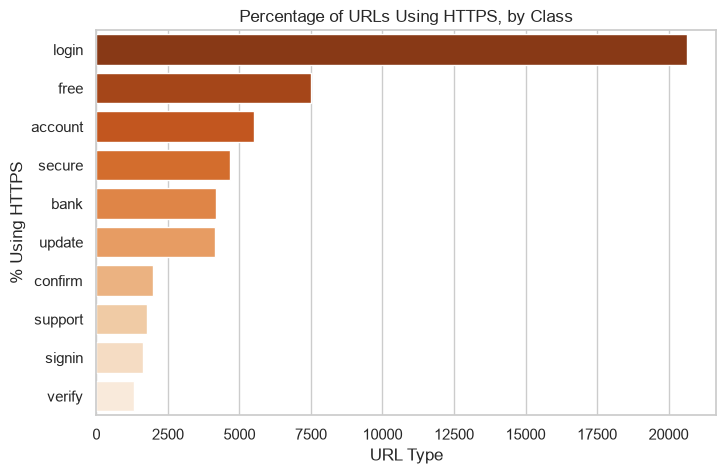

In [13]:
https_by_type = df_final.groupby("type")["has_https"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, hue=top_keywords.index, palette="Oranges_r", legend=False)
plt.title("Percentage of URLs Using HTTPS, by Class")
plt.xlabel("URL Type")
plt.ylabel("% Using HTTPS")
plt.savefig(GRAPH_DIR / "03_https_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 — Most common suspicious keywords

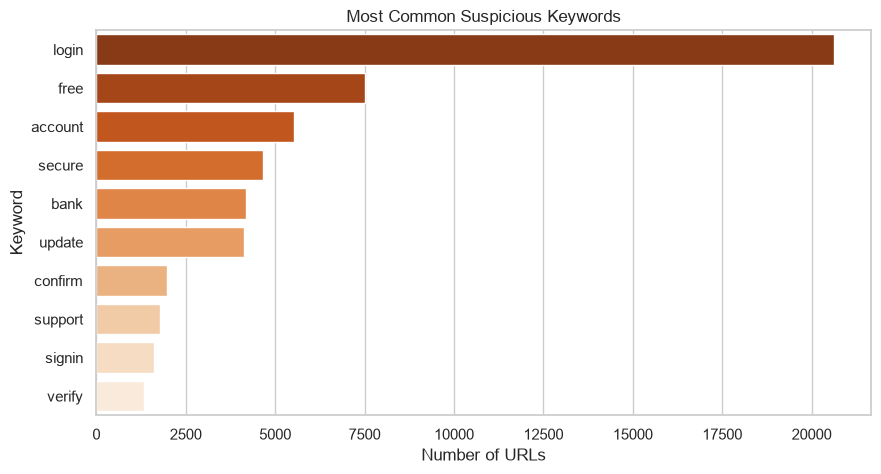

In [10]:
keyword_series = df_final["suspicious_keyword"].str.split(", ").explode()
keyword_series = keyword_series[keyword_series != "none"]

top_keywords = keyword_series.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, hue=top_keywords.index, palette="Oranges_r", legend=False)
plt.title("Most Common Suspicious Keywords")
plt.xlabel("Number of URLs")
plt.ylabel("Keyword")
plt.savefig(GRAPH_DIR / "04_suspicious_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 5 — Correlation heatmap

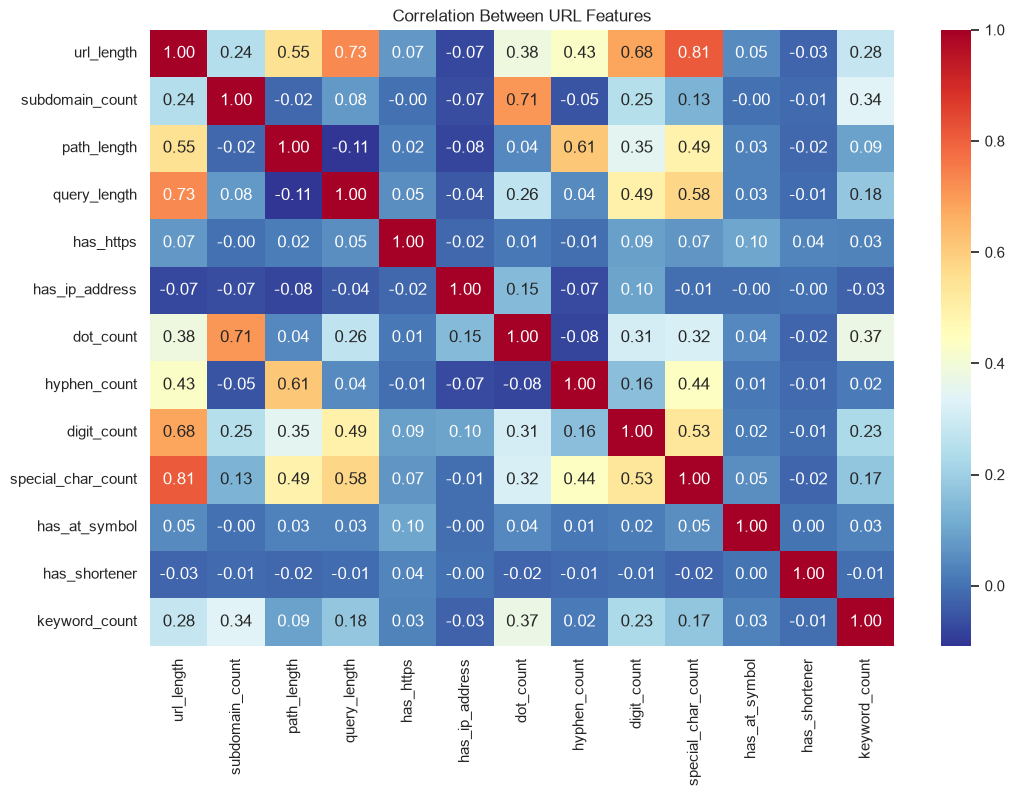

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlBu_r", fmt=".2f")
plt.title("Correlation Between URL Features")
plt.savefig(GRAPH_DIR / "05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 6 — URL length vs digit count, colored by class

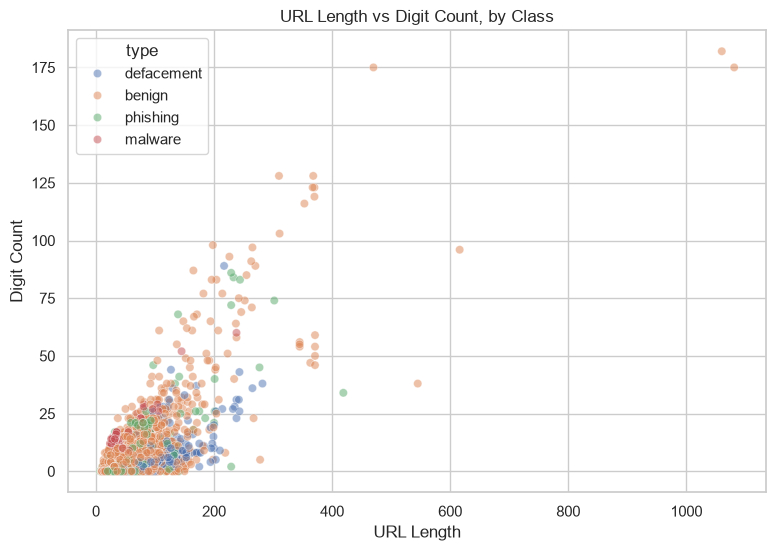

In [8]:
sample_df = df_final.sample(min(4000, len(df_final)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample_df, x="url_length", y="digit_count", hue="type", alpha=0.5)
plt.title("URL Length vs Digit Count, by Class")
plt.xlabel("URL Length")
plt.ylabel("Digit Count")
plt.savefig(GRAPH_DIR / "06_length_vs_digits.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 7 — Confusion matrix (classifier from Stage 6)

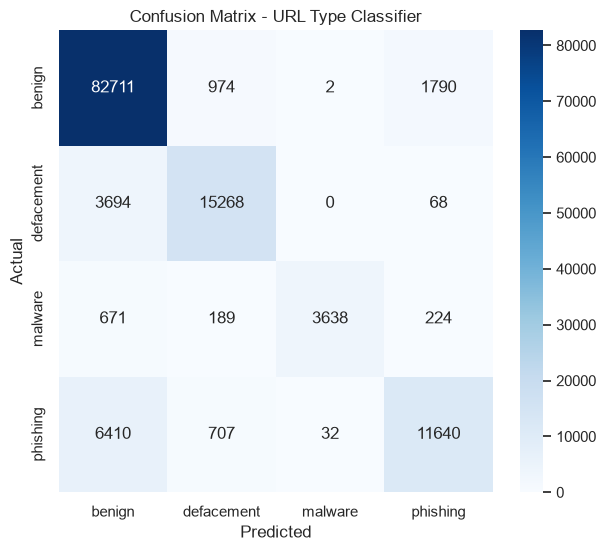

In [9]:
class_names = sorted(pred["actual"].unique())
cm = confusion_matrix(pred["actual"], pred["predicted"], labels=class_names)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - URL Type Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(GRAPH_DIR / "07_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
